<center>



### **Initial orientation and Getting to know the dataset**


**Load and show an image**

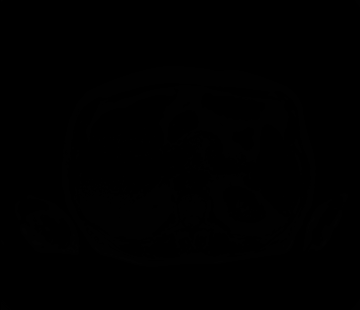

In [1]:
from PIL import Image

img_path = "/Users/ali/Desktop/madison/train/case133/case133_day23/scans/slice_0070_360_310_1.50_1.50.png"
img = Image.open(img_path)
img

In [6]:
img.format, img.size, img.mode

('PNG', (360, 310), 'I;16')

As we can see the mode of images is (I-16). "I" refers to the fact that the image has 1 channel (if image has one channel it is represented as I, and if the image has three channels it is reperesented as RGB). 16 means the image is 16 bit instead of the conventional 8 bit. 
Pixel values in 8 bit images range from 0 to 255 but in 16 bit images, it ranges from 0 to 65535
Lets convert PIL images to tensors (or numpy array) to see pixel values

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F
import torchvision.transforms.functional as F
img_tensor = F.to_tensor(img)
img_tensor.shape, img_tensor.dtype, img_tensor.min(), img_tensor.max()

(torch.Size([1, 310, 360]),
 torch.int16,
 tensor(0, dtype=torch.int16),
 tensor(603, dtype=torch.int16))

In [4]:
import numpy as np
img_nparray = np.array (img)
img_nparray.shape, img_nparray.dtype, img_nparray.min(), img_nparray.max()

((310, 360), dtype('uint16'), np.uint16(0), np.uint16(603))

for a given image:
PIL --> img.size --> (width, height); if we want to see the number of channels--> img.mode --> I means 1 channel and RGB means 3 channels
Numpy.array --> (height, width, channels). if channel =1 then it does not show the number of channels
Torch.tensor -->(channels, height, width)

the output of min(), max() commands above may confuse you.
The images we have in our database are 16bit images and their pixel values can range from 0 to 65535.
but as you can see the max() command says the max value is 296
They """CAN""" range from 0 to 65535 but these images are humble and actually have taken on pixel values ranging from 0 to only 296.
This is also why we see them as black empty images. PIL (and other computer vision packages) says, well, I am dealing with a 16 bit image, so I can have pixel values from 0 to 65535. I will render "pure black" color to value 0 and "pure white" color to value 65535. 
Our actual images in this dataset have taken on only values from 0 to 296. The PIL interperts this condition like the images are in fact very black.

To tackle this problem we can open our images using matplotlibe. matplotlib is internally programmed so that it first screens the whole pixle values given to it, then treats the max value in the given data as the max value possible and min value in the data as the min value possible. **THUS** the condition we explained above for computer vision packages does not occur for matplotlib and we can see the actual images with appropriate contrast.

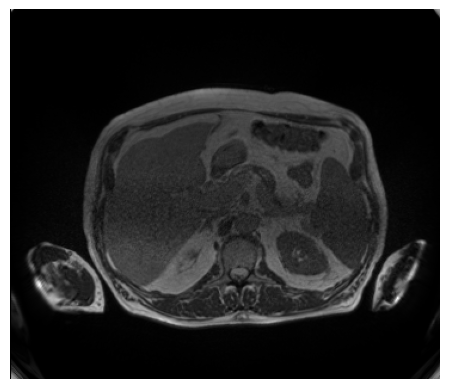

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(img_tensor[0], cmap='gray')
plt.axis('off');

Ok Done... Just a quick note:
Later in this project where we want to give pixle values to the model, we must remember that NNs need values between 0 and 1. So we will need to normalize our data-->

In [7]:
def my_normalizer (x):
    return (x - x.min()) / (x.max() - x.min())

In [9]:
img_norm = my_normalizer(img_tensor)
img_norm.dtype, img_norm.min(), img_norm.max(), img_norm.shape, img_norm.dtype

(torch.float32,
 tensor(0.),
 tensor(1.),
 torch.Size([1, 310, 360]),
 torch.float32)

If we give the normalized pixel values to matplotlibe, it will again show the images correctly--->

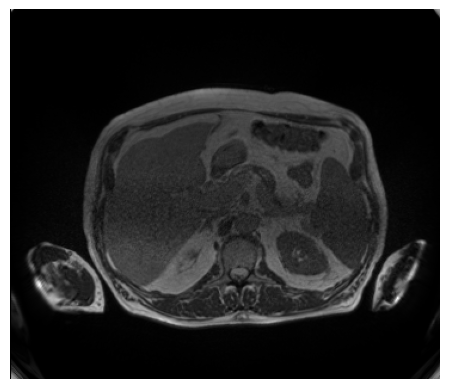

In [10]:
plt.imshow(img_norm[0], cmap='gray')
plt.axis('off');

**Load and show a segmentation mask**

In [11]:
import pandas as pd
df = pd.read_csv('/Users/ali/Desktop/madison/train.csv')
df.head()

,id,class,segmentation
0,case123_day20_slice_0001,large_bowel,NaN
1,case123_day20_slice_0001,small_bowel,NaN
2,case123_day20_slice_0001,stomach,NaN
3,case123_day20_slice_0002,large_bowel,NaN
4,case123_day20_slice_0002,small_bowel,NaN


Above code reads the csv file in a way that the python itself adds a separate index column.
I want to treat the "id" column in the csv file as the primary index column--->

In [12]:
df = pd.read_csv('/Users/ali/Desktop/madison/train.csv', index_col= 'id')
df.head()

,class,segmentation
id,,
case123_day20_slice_0001,large_bowel,NaN
case123_day20_slice_0001,small_bowel,NaN
case123_day20_slice_0001,stomach,NaN
case123_day20_slice_0002,large_bowel,NaN
case123_day20_slice_0002,small_bowel,NaN


Ok lets now choose a given segmentation data

In [13]:
Given_sample_id = 'case133_day23_slice_0070'

In [14]:
sample = df.loc [Given_sample_id]
sample

,class,segmentation
id,,
case133_day23_slice_0070,large_bowel,34047 8 34405 15 34429 2 34765 30 35124 34 354...
case133_day23_slice_0070,small_bowel,48411 7 48769 10 49129 11 49489 11 49848 12 50...
case133_day23_slice_0070,stomach,39785 9 40143 13 40501 16 40859 19 41217 22 41...


In [15]:
rle_mask_for_large_bowel = sample.iloc [0, 1]
rle_mask_for_large_bowel

'34047 8 34405 15 34429 2 34765 30 35124 34 35484 37 35843 42 36203 52 36563 55 36922 62 37282 64 37642 66 38003 65 38363 66 38724 65 39085 64 39450 58 39812 56 40173 54 40535 51 40897 48 41258 45 41621 41 41985 36 42347 34 42712 29 43079 22 43443 3 43453 7 43814 5 44174 4 44534 4 44893 4 45252 5 45607 10 45964 13 46321 15 46679 17 47037 19 47396 20 47756 20 48115 21 48475 21 48835 21 49194 22 49554 22 49914 22 50275 21 50635 21 50995 21 51356 20 51717 19 52079 17 52441 15 52802 14 53164 12 53526 9 53887 7 54249 4'

Mask sheets in segmentation projects are comprised of 0 and 1 values
Almost all values are 0 and few of them are 1
The file sizes are usually high
Kaggle has develloped a method for representing the pixle values of the masks
This method is called RLE
The RLE format occupies less amount of memory
We can simply decode RLE to 0/1 format using these lines of code provided by Dr chatgpt:

In [16]:
##### RLE to Binary #####

import numpy as np

def rle_to_binary(rle, shape):
    """    
    Args:
        rle (list): List of integers [start1, length1, start2, length2, ...]
        shape (tuple): (height, width)
        
    Returns:
        2D binary mask: mask (np.ndarray)
    """
    #first check if the RLE format is stored as a string format or as a list.
    #if stored as string, we must first convert it to a list, but if this is already a list, we are good to go

    if isinstance(rle, str):
        rle = [int(x) for x in rle.split()]

    # Initialize a base mask with zeros
    mask = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    
    # Iterate through the RLE pairs
    for i in range(0, len(rle), 2):
        start = rle[i] - 1  # RLE is often 1-indexed
        length = rle[i+1]
        mask[start : start + length] = 1
        
    # Reshape to original image dimensions
    # Note: RLEs are often column-major (order='F'). Adjust to 'C' if needed.
    return mask.reshape(shape, order='F')

In [17]:
mask = rle_to_binary (rle_mask_for_large_bowel, (310,360)) #because the shape of the slice image is 310*360 (Height, Width)
mask, mask.shape

(array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
 (310, 360))

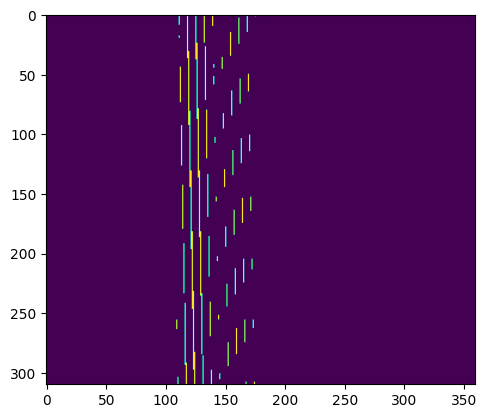

In [18]:
plt.imshow(mask)

Where is the problem???
Lets first check our understanding of row-wise and column-wise reshaping

In [19]:
random_example = np.random.randint(0, 10, size=(1, 6))
random_example

array([[6, 7, 1, 6, 2, 8]])

In [20]:
Method_C = random_example.reshape((3,2), order='C')
Method_F = random_example.reshape((3,2), order='F')

Method_C, Method_F

(array([[6, 7],
        [1, 6],
        [2, 8]]),
 array([[6, 6],
        [7, 2],
        [1, 8]]))

Usually RLE is stored in column-wise order but this specific dataset has stored data in row-wise order.
So we have to change the reshape section of the rle_to_binary def
F--->C

In [21]:
##### RLE to Binary #####

import numpy as np

def rle_to_binary(rle, shape):
    """    
    Args:
        rle (list): List of integers [start1, length1, start2, length2, ...]
        shape (tuple): (height, width)
        
    Returns:
        2D binary mask: mask (np.ndarray)
    """
    #first check if the RLE format is stored as a string format or as a list.
    #if stored as string, we must first convert it to a list, but if this is already a list, we are good to go

    if isinstance(rle, str):
        rle = [int(x) for x in rle.split()]

    # Initialize a base mask with zeros
    mask = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    
    # Iterate through the RLE pairs
    for i in range(0, len(rle), 2):
        start = rle[i] - 1  # RLE is often 1-indexed
        length = rle[i+1]
        mask[start : start + length] = 1
        
    # Reshape to original image dimensions
    # Note: RLEs are often column-major (order='F'). Adjust to 'C' if needed.
    return mask.reshape(shape, order='C')

Lets now recheck:

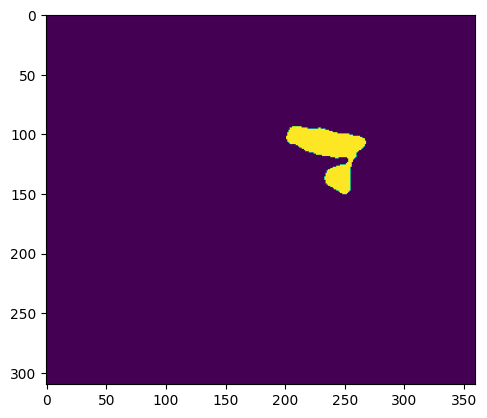

In [22]:
mask = rle_to_binary (rle_mask_for_large_bowel, (310,360)) #because the shape of the slice image is 310*360 (Height, Width)
plt.imshow(mask)

Awesome!!!

Lets now put the mask on the slice image

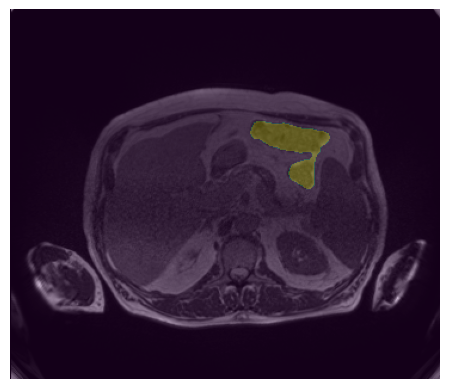

In [23]:
plt.imshow(img_tensor[0], cmap='gray')
plt.imshow(mask, alpha=0.3)
plt.axis('off');

Ok lets now impose all three masks on the slice image

In [24]:
rle_mask_for_large_bowel = sample.iloc [0, 1]
rle_mask_for_small_bowel = sample.iloc [1, 1]
rle_mask_for_stomach = sample.iloc [2, 1]

mask1 = rle_to_binary (rle_mask_for_large_bowel, (310,360))
mask2 = rle_to_binary (rle_mask_for_small_bowel, (310,360))
mask3 = rle_to_binary (rle_mask_for_stomach, (310,360))

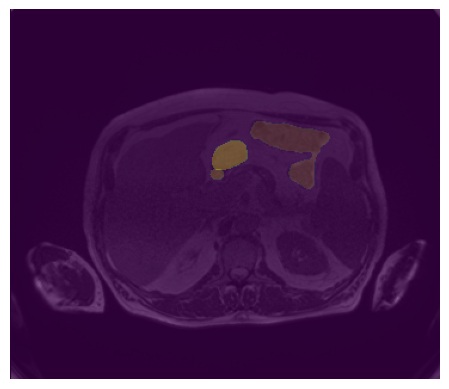

In [25]:
plt.imshow(img_tensor [0], cmap='gray')
plt.imshow(mask1, alpha=0.3)
plt.imshow(mask2, alpha=0.3)
plt.imshow(mask3, alpha=0.3)
plt.axis('off');

Worked correctly but contrast is very low. lets somehow fix it

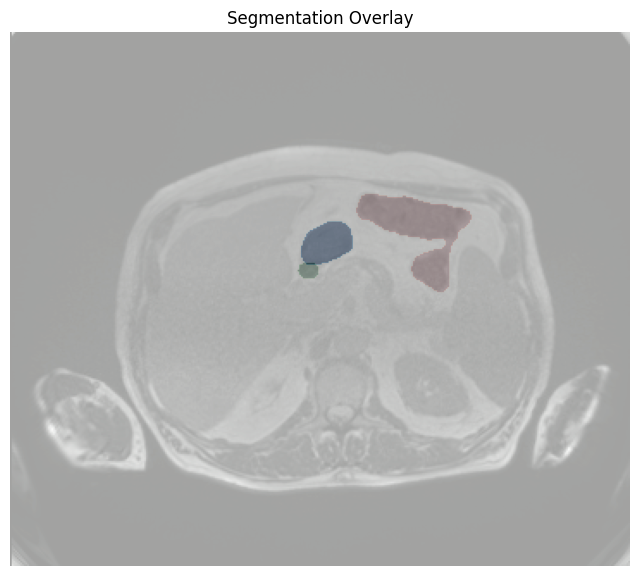

In [26]:
plt.figure(figsize=(8, 8))
plt.imshow(img_tensor[0], cmap='gray')

# 2. Plot each mask with a specific color and distinct alpha
# Using different colormaps (Reds, Greens, Blues) makes them distinguishable
plt.imshow(mask1, cmap='Reds', alpha=0.3)   # Large Bowel
plt.imshow(mask2, cmap='Greens', alpha=0.3) # Small Bowel
plt.imshow(mask3, cmap='Blues', alpha=0.3)  # Stomach

plt.axis('off')
plt.title("Segmentation Overlay")
plt.show()

Isnt it possible to get a better contrast???

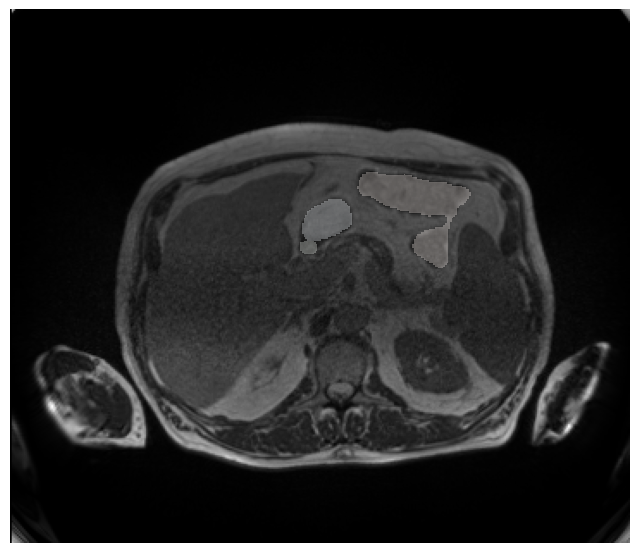

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create a "masked" version of your mask
# This tells python: "If the value is 0 (background), treat it as transparent"
masked_mask1 = np.ma.masked_where(mask1 == 0, mask1)
masked_mask2 = np.ma.masked_where(mask2 == 0, mask2)
masked_mask3 = np.ma.masked_where(mask3 == 0, mask3)

plt.figure(figsize=(8,8))

# 2. Show the original image
plt.imshow(img_tensor[0], cmap='gray')

# Because we used masked_where, it ONLY colors the bowel area, not the entire image background!

plt.imshow(masked_mask1, cmap='Reds', alpha=0.3)
plt.imshow(masked_mask2, cmap='Greens', alpha=0.3)
plt.imshow(masked_mask3, cmap='Blues', alpha=0.3)

plt.axis('off')
plt.show()


Worked good but why the mask colors didnt follow as we programmed?

This happens because plt.imshow is trying to interpret your mask data. If the mask data itself is just 0s and 1s, matplotlib sometimes defaults to a grayscale colormap unless you explicitly tell it otherwise, or if there’s a conflict with the global settings.

The fix is to explicitly define the color mapping using vmin and vmax arguments. This forces matplotlib to map the 1 (your mask) to the full intensity of the color you chose.

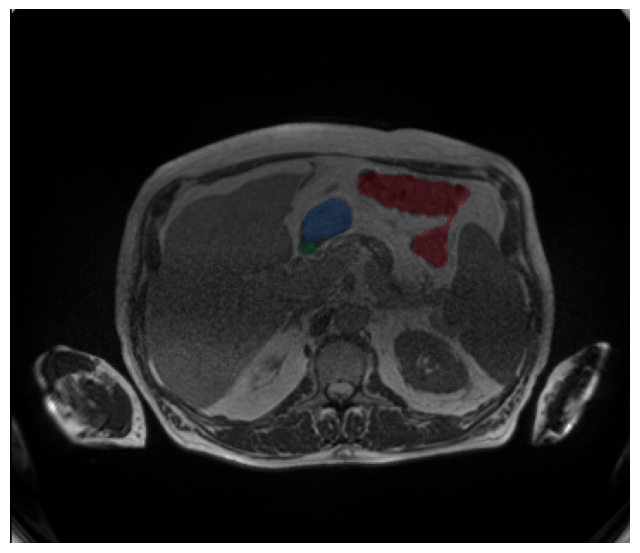

In [28]:
plt.figure(figsize=(8,8))

# 2. Show the original image
plt.imshow(img_tensor[0], cmap='gray')

# vmin=0 and vmax=1 tells matplotlib that 1 is the 'highest' color intensity
plt.imshow(masked_mask1, cmap='Reds', alpha=0.4, vmin=0, vmax=1)
plt.imshow(masked_mask2, cmap='Greens', alpha=0.4, vmin=0, vmax=1)
plt.imshow(masked_mask3, cmap='Blues', alpha=0.4, vmin=0, vmax=1)
plt.axis('off')
plt.show()

lets impose mask contours not the solid masks. This is the most professional way in segmentation tasks. I copy the codes from chatgpt.

/var/folders/h4/vtlmm4xd3lscskmlb0fy218m0000gn/T/ipykernel_872/3990979370.py:38: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(loc='upper right')
/var/folders/h4/vtlmm4xd3lscskmlb0fy218m0000gn/T/ipykernel_872/3990979370.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


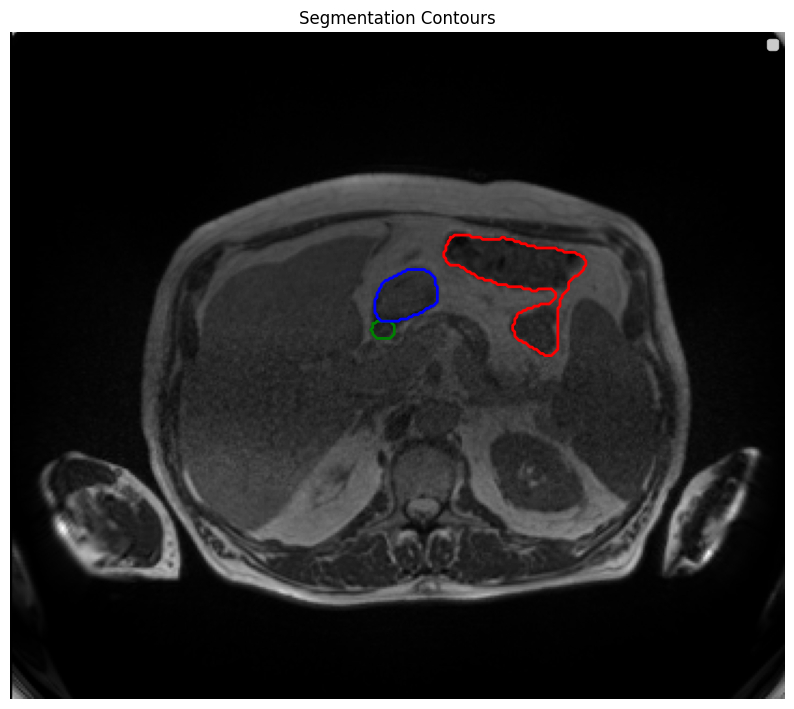

In [29]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def get_contours(mask):
    """Returns the contours of a binary mask as a list."""
    # Ensure mask is uint8 (OpenCV requirement)
    mask = mask.astype(np.uint8)
    
    # RETR_EXTERNAL gets the outside boundary of the mask
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    return contours

def plot_segmentation_contours(img, masks, colors, labels):
    """
    Args:
        img: The original grayscale image (H, W)
        masks: List of masks [mask1, mask2, mask3]
        colors: List of colors ['red', 'green', 'blue']
        labels: List of legend labels ['Large Bowel', 'Small Bowel', 'Stomach']
    """
    plt.figure(figsize=(10, 10))
    plt.imshow(img, cmap='gray')
    
    for mask, color, label in zip(masks, colors, labels):
        # Only plot if there is content in the mask
        if np.sum(mask) > 0:
            contours = get_contours(mask)
            # Draw contours on the existing plot
            # thickness=2 makes the line visible
            plt.gca().add_collection(
                plt.matplotlib.collections.PatchCollection(
                    [plt.matplotlib.patches.Polygon(c.reshape(-1, 2)) for c in contours],
                    edgecolor=color, facecolor='none', linewidth=2, label=label
                )
            )
            
    plt.legend(loc='upper right')
    plt.axis('off')
    plt.title("Segmentation Contours")
    plt.show()

# --- Usage ---
# Assuming img_tensor[0] is your image, and masks are your binary arrays
masks = [mask1, mask2, mask3]
colors = ['red', 'green', 'blue']
labels = ['Large Bowel', 'Small Bowel', 'Stomach']

plot_segmentation_contours(img_tensor[0], masks, colors, labels)
